# 03 · Backtest de origen móvil

El objetivo SMART del proyecto: **reducir MASE al menos 20 %** frente al naive estacional,
medido sobre 8 orígenes con horizonte de 7 días.

Dos reglas que gobiernan este notebook:

1. **Ninguna métrica va como número único.** Todas van con su dispersión entre orígenes y con
   el peor origen. Un promedio bueno puede esconder un origen catastrófico, y el origen
   catastrófico es el que pasa en producción.
2. **Los baselines no están elegidos para perder.** Croston y la media móvil de 21 días le
   ganan al naive estacional por ~18 %, así que la mejora del modelo global no se mide contra
   un hombre de paja.

## Sobre el alcance de esta corrida

El reporte oficial sale de `make models`, que corre las 3.066 series con 8 orígenes y tarda
decenas de minutos. Acá se corre una versión reducida y **declarada** para que el notebook sea
reproducible en minutos. Si el parquet oficial existe en `reports/`, se carga y se comparan
las dos.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from blindside import config as cfg
from blindside.data import loaders
from blindside.data import schema as S
from blindside.evaluate import contracts as C
from blindside.evaluate import metrics as M

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (9, 3.2), "axes.grid": True, "grid.alpha": 0.25})

panel = loaders.load_demand()
rng = np.random.default_rng(cfg.SEED)
elegidas = set(rng.choice(sorted(panel[S.SERIES_ID].astype(str).unique()), 400, replace=False))
chico = panel[panel[S.SERIES_ID].astype(str).isin(elegidas)]

# Configuración reducida y declarada: 4 orígenes en vez de 8.
forecast = cfg.ForecastConfig(
    horizon=cfg.FORECAST.horizon,
    season_length=cfg.FORECAST.season_length,
    n_origins=4,
    step=cfg.FORECAST.step,
    min_train_days=cfg.FORECAST.min_train_days,
    coverage=cfg.FORECAST.coverage,
)
print(f"panel completo : {panel[S.SERIES_ID].nunique():,} series")
print(f"este notebook  : {chico[S.SERIES_ID].nunique()} series · {forecast.n_origins} orígenes")
print(f"oficial        : {panel[S.SERIES_ID].nunique():,} series · {cfg.FORECAST.n_origins} orígenes (make models)")

panel completo : 3,066 series
este notebook  : 400 series · 4 orígenes
oficial        : 3,066 series · 8 orígenes (make models)


## 1 · El contrato de resultado

Todo lo que sigue consume **una sola forma**: el contrato de backtest
(`src/blindside/evaluate/contracts.py`). Métricas, dashboard y API leen de ahí, así que agregar
un modelo no obliga a tocar nada de lo que viene después.

In [2]:
from blindside.evaluate.backtest import run_backtest
from blindside.models.baselines import make_baselines
from blindside.models.gbdt import LightGBMForecaster
from blindside.models.linear import RidgeForecaster

modelos = [*make_baselines(season_length=forecast.season_length), LightGBMForecaster(), RidgeForecaster()]
print("modelos:", [m.name for m in modelos])

resultado = run_backtest(chico, modelos, target=S.DEMAND_LATENT, forecast=forecast)
print(f"\nfilas de resultado: {len(resultado):,}")
print(f"columnas del contrato: {list(resultado.columns)}")

modelos: ['naive', 'seasonal_naive', 'moving_average', 'seasonal_moving_average', 'croston_sba', 'lgbm_global', 'ridge']



filas de resultado: 78,400
columnas del contrato: ['series_id', 'dt', 'h', 'y_pred', 'y_observed', 'is_censored', 'available_weight', 'y_true', 'model', 'origin', 'origin_date', 'naive_scale']


## 2 · La tabla principal: MASE con dispersión

`summarize` devuelve media, desvío, peor y mejor origen. La columna **peor origen** es la que
responde «qué pasa el mes que sale mal».

In [3]:
resumen = M.summarize(resultado)
mase = resumen[resumen["metric"] == "mase"].sort_values("mean").reset_index(drop=True)
display(
    mase[["model", "mean", "std", "worst_origin", "best_origin", "n_origins"]].round(4)
)

,model,mean,std,worst_origin,best_origin,n_origins
0,lgbm_global,0.8711,0.0142,0.8869,0.8537,4
1,ridge,0.9337,0.0309,0.9749,0.9073,4
2,croston_sba,0.9415,0.0236,0.9645,0.9142,4
3,moving_average,0.9505,0.0220,0.9726,0.9298,4
4,seasonal_moving_average,0.9972,0.0170,1.0135,0.9805,4
5,seasonal_naive,1.1527,0.0164,1.1667,1.1300,4
6,naive,1.2065,0.0860,1.2765,1.0940,4


In [4]:
mejora = M.improvement_vs_baseline(resumen, baseline="seasonal_naive", metric="mase")
display(mejora.round(4))

ganadores = mejora[mejora["meets_target_20pct"]]["model"].tolist()
print(f"\nmodelos que cumplen el objetivo del 20 %: {ganadores or 'ninguno en esta corrida reducida'}")

,model,mean,std,worst_origin,n_origins,improvement_pct,beats_baseline,meets_target_20pct
0,lgbm_global,0.8711,0.0142,0.8869,4,24.4316,True,True
1,ridge,0.9337,0.0309,0.9749,4,18.9963,True,False
2,croston_sba,0.9415,0.0236,0.9645,4,18.3244,True,False
3,moving_average,0.9505,0.0220,0.9726,4,17.5451,True,False
4,seasonal_moving_average,0.9972,0.0170,1.0135,4,13.4911,True,False
5,seasonal_naive,1.1527,0.0164,1.1667,4,0.0000,False,False
6,naive,1.2065,0.0860,1.2765,4,-4.6695,False,False



modelos que cumplen el objetivo del 20 %: ['lgbm_global']


### Por qué el naive estacional da MASE ≈ 1,10 y no 1,00

Es la pregunta que aparece primero al leer la tabla, y la respuesta es la definición estándar:
el **denominador** de MASE es el error *en muestra* del naive estacional sobre el train de cada
fold, y el **numerador** es *fuera de muestra*.

Que el segundo sea mayor que el primero es lo normal. Un MASE de 1,00 para el naive estacional
solo ocurriría si su error fuera de muestra fuese idéntico al de dentro, o sea si la serie no
tuviera nada nuevo.

La celda de abajo lo verifica en lugar de afirmarlo: compara la escala del fold (en muestra)
contra el error real del naive estacional (fuera de muestra).

In [5]:
sn = resultado[resultado[C.MODEL] == "seasonal_naive"]
error_fuera = float(np.abs(sn[C.Y_TRUE] - sn[C.Y_PRED]).mean())
escala_dentro = float(sn[C.NAIVE_SCALE].mean())
print(f"error absoluto medio FUERA de muestra (numerador) : {error_fuera:.4f}")
print(f"escala EN muestra del train  (denominador)        : {escala_dentro:.4f}")
print(f"cociente aproximado                              : {error_fuera / escala_dentro:.4f}")
print("\nMASE se calcula fila por fila y no con estos promedios, así que el cociente")
print("de arriba es orientativo. Lo que muestra es de dónde sale el >1.")

error absoluto medio FUERA de muestra (numerador) : 0.6652
escala EN muestra del train  (denominador)        : 0.6022
cociente aproximado                              : 1.1046

MASE se calcula fila por fila y no con estos promedios, así que el cociente
de arriba es orientativo. Lo que muestra es de dónde sale el >1.


## 3 · Dispersión entre orígenes

Acá se ve si el promedio es honesto. Un modelo con media buena y desvío grande es un modelo
que a veces falla mucho, y en reposición eso cuesta más que un promedio algo peor y estable.

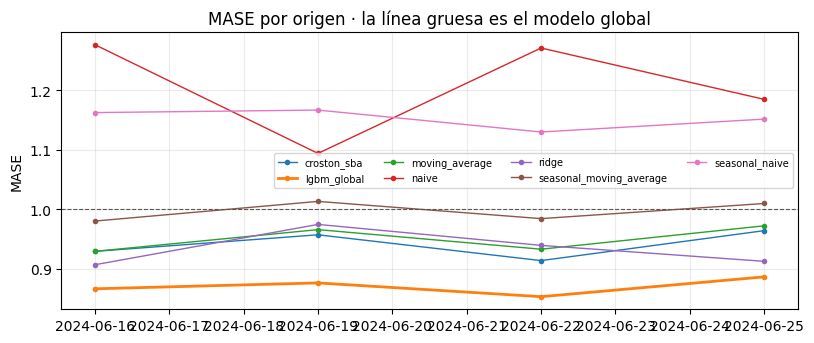

model,croston_sba,lgbm_global,moving_average,naive,ridge,seasonal_moving_average,seasonal_naive
origin_date,,,,,,,
2024-06-16,0.9297,0.8669,0.9298,1.2765,0.9073,0.9805,1.1625
2024-06-19,0.9575,0.8768,0.9662,1.0940,0.9749,1.0135,1.1667
2024-06-22,0.9142,0.8537,0.9334,1.2709,0.9398,0.9847,1.1300
2024-06-25,0.9645,0.8869,0.9726,1.1847,0.9130,1.0100,1.1516


In [6]:
por_origen = M.metrics_by_origin(resultado)
pivote = por_origen.pivot_table(index=C.ORIGIN_DATE, columns=C.MODEL, values="mase")

fig, eje = plt.subplots(figsize=(9.5, 3.6))
for col in pivote.columns:
    ancho = 2.0 if col == "lgbm_global" else 1.0
    eje.plot(pivote.index, pivote[col], marker="o", ms=3, lw=ancho, label=col)
eje.axhline(1.0, color="#5A5550", lw=0.8, ls="--")
eje.set_ylabel("MASE")
eje.set_title("MASE por origen · la línea gruesa es el modelo global")
eje.legend(fontsize=7, ncol=4)
plt.show()

display(pivote.round(4))

## 4 · Degradación con el horizonte

Responde «cuánto dura el modelo». Y hay un detalle que conviene anticipar: **el error no es
monótono en `h`**, y eso no es un bug.

Con estacionalidad semanal y `m = 7`, el objetivo en `T+7` cae el mismo día de la semana que
`T`, así que se le parece **más** que el de `T+1`. Para el naive estacional el error es plano
en `h` por construcción: todos los pasos usan un valor a exactamente 7 días de su objetivo.

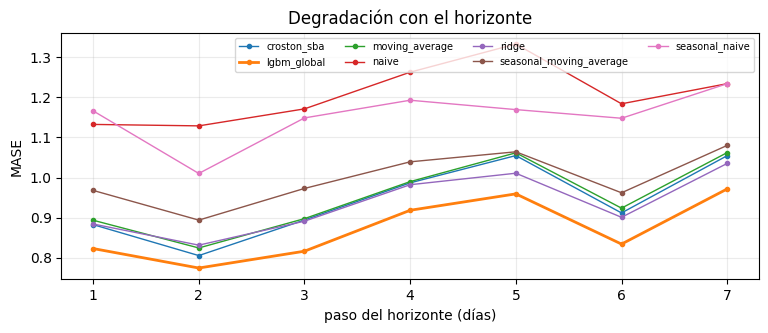

model,croston_sba,lgbm_global,moving_average,naive,ridge,seasonal_moving_average,seasonal_naive
h,,,,,,,
1,0.8827,0.8231,0.8936,1.1324,0.8842,0.9680,1.1662
2,0.8055,0.7745,0.8245,1.1288,0.8315,0.8940,1.0102
3,0.8942,0.8164,0.8976,1.1712,0.8913,0.9729,1.1486
4,0.9868,0.9184,0.9899,1.2626,0.9821,1.0392,1.1927
5,1.0548,0.9593,1.0616,1.3328,1.0108,1.0642,1.1694
6,0.9118,0.8342,0.9238,1.1838,0.9009,0.9620,1.1478
7,1.0545,0.9716,1.0622,1.2340,1.0352,1.0801,1.2340


In [7]:
por_h = M.metrics_by_horizon(resultado)
pivote_h = por_h.pivot_table(index=C.HORIZON_STEP, columns=C.MODEL, values="mase")

fig, eje = plt.subplots()
for col in pivote_h.columns:
    ancho = 2.0 if col == "lgbm_global" else 1.0
    eje.plot(pivote_h.index, pivote_h[col], marker="o", ms=3, lw=ancho, label=col)
eje.set_xlabel("paso del horizonte (días)")
eje.set_ylabel("MASE")
eje.set_title("Degradación con el horizonte")
eje.legend(fontsize=7, ncol=4)
plt.show()

display(pivote_h.round(4))

## 5 · Dónde falla el modelo: por banda de rotación

Un MASE global bueno puede esconder que el modelo falla justo en la cola del catálogo, que es
la mayoría de los SKU. Esta es la tabla que conviene tener lista antes de que la pregunte el
panel.

In [8]:
from blindside.validation.splits import rotation_bands

bandas = rotation_bands(chico, target=S.DEMAND_LATENT)
por_banda = M.metrics_by_group(resultado, bandas, name="banda")
display(por_banda.pivot_table(index=C.MODEL, columns="banda", values="mase").round(4))
print("Los tamaños de grupo no son informativos: las bandas son cortes por cuantil.")
print("Lo informativo es si algún modelo se derrumba en una banda y no en otra.")

banda,alta,baja,media
model,,,
croston_sba,1.1068,0.9226,0.8977
lgbm_global,0.9420,0.8636,0.8513
moving_average,1.1267,0.9272,0.9082
naive,1.2523,1.2392,1.1402
ridge,0.9958,0.9420,0.8953
seasonal_moving_average,1.1560,0.9760,0.9595
seasonal_naive,1.2163,1.1594,1.1159


Los tamaños de grupo no son informativos: las bandas son cortes por cuantil.
Lo informativo es si algún modelo se derrumba en una banda y no en otra.


## 6 · Días con quiebre contra días limpios

El target es demanda latente recuperada. En los días con quiebre esa demanda es una
**estimación**, no una observación, así que el MASE de esos días mide el pronóstico *y* la
corrección juntos. Separarlos es la única forma honesta de leerlo.

In [9]:
censura = M.censoring_metrics(resultado)
display(
    censura[["model", "mase_clean", "mase_censored", "n_clean_days", "n_censored_days"]]
    .sort_values("mase_clean")
    .round(4)
)
print("`mase_clean` es el número con verdad de terreno real: esos días no se tocaron.")
print("La ablación pareada que aísla el efecto de la censura está en `make ablation`.")

,model,mase_clean,mase_censored,n_clean_days,n_censored_days
1,lgbm_global,0.6479,1.1750,6458,4742
0,croston_sba,0.6483,1.3408,6458,4742
2,moving_average,0.6686,1.3343,6458,4742
5,seasonal_moving_average,0.7166,1.3794,6458,4742
4,ridge,0.7482,1.1864,6458,4742
6,seasonal_naive,0.9087,1.4850,6458,4742
3,naive,1.0280,1.4496,6458,4742


`mase_clean` es el número con verdad de terreno real: esos días no se tocaron.
La ablación pareada que aísla el efecto de la censura está en `make ablation`.


## 7 · Contra el reporte oficial, si está en disco

`make models` guarda `reports/backtest_models.parquet` con las 3.066 series y 8 orígenes. Si
existe, esta celda compara las dos corridas — sirve para ver cuánto del resultado depende del
tamaño del panel y cuánto del modelo.

In [10]:
oficial_path = cfg.REPORTS / "backtest_models.parquet"
if not oficial_path.exists():
    print(f"no está {oficial_path.name}: correr 'make models' para generarlo.")
    print("Los números de arriba son de la corrida reducida de este notebook.")
else:
    oficial = pd.read_parquet(oficial_path)
    res_of = M.summarize(oficial)
    mase_of = res_of[res_of["metric"] == "mase"].set_index("model")["mean"]
    comparacion = pd.DataFrame(
        {
            "este notebook": mase.set_index("model")["mean"],
            "oficial (make models)": mase_of,
        }
    ).dropna(how="all")
    comparacion["Δ"] = comparacion["oficial (make models)"] - comparacion["este notebook"]
    display(comparacion.round(4))

,este notebook,oficial (make models),Δ
model,,,
cqr_lgbm_quantile,NaN,0.8217,NaN
croston_sba,0.9415,0.8952,-0.0462
lgbm_global,0.8711,0.8222,-0.0489
moving_average,0.9505,0.9048,-0.0457
naive,1.2065,1.1606,-0.0459
ridge,0.9337,0.9018,-0.0319
seasonal_moving_average,0.9972,0.9460,-0.0511
seasonal_naive,1.1527,1.1002,-0.0525


## Lo que sale de acá

- El arnés de backtesting produce **una sola forma** de resultado, y todo lo demás la consume.
- Las métricas van con dispersión entre orígenes y con el peor origen, nunca como número único.
- El naive estacional da MASE > 1 por definición, no por un error de cálculo.
- El error no es monótono en el horizonte, y con estacionalidad semanal eso es lo esperable.
- Desagregar por banda de rotación y por día limpio/censurado es lo que evita que un promedio
  bueno tape un subgrupo malo.

**Sigue:** `04_no_supervisado.ipynb` — estructura del catálogo sin etiquetas.